In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
df = pd.read_csv('Hospital_Inpatient_Cost_Transparency__Beginning.csv')  
df.head()


,Year,Facility Id,Facility Name,APR DRG Code,APR Severity of Illness Code,APR DRG Description,APR Severity of Illness Description,APR Medical Surgical Code,APR Medical Surgical Description,Discharges,Mean Charge,Median Charge,Mean Cost,Median Cost
0,2016,4,Albany Memorial Hospital,194,1,Heart Failure,Minor,M,Medical,2,8375.41,8375.41,3585.05,3585.05
1,2016,4,Albany Memorial Hospital,194,2,Heart Failure,Moderate,M,Medical,40,14029.82,12176.95,6182.67,5253.15
2,2016,4,Albany Memorial Hospital,194,3,Heart Failure,Major,M,Medical,70,23921.77,20229.81,11149.49,9068.10
3,2016,4,Albany Memorial Hospital,194,4,Heart Failure,Extreme,M,Medical,12,51260.45,35210.82,26081.70,15230.62
4,2016,4,Albany Memorial Hospital,196,4,Cardiac Arrest,Extreme,M,Medical,1,25357.84,25357.84,7791.75,7791.75


In [27]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1081672 entries, 0 to 1081671
Data columns (total 14 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   Year                                 1081672 non-null  int64  
 1   Facility Id                          1081672 non-null  int64  
 2   Facility Name                        1081672 non-null  object 
 3   APR DRG Code                         1081672 non-null  int64  
 4   APR Severity of Illness Code         1081672 non-null  int64  
 5   APR DRG Description                  1081672 non-null  object 
 6   APR Severity of Illness Description  1081462 non-null  object 
 7   APR Medical Surgical Code            1081330 non-null  object 
 8   APR Medical Surgical Description     1081672 non-null  object 
 9   Discharges                           1081672 non-null  int64  
 10  Mean Charge                          1081672 non-null  float64
 11

Year                                     0
Facility Id                              0
Facility Name                            0
APR DRG Code                             0
APR Severity of Illness Code             0
APR DRG Description                      0
APR Severity of Illness Description    210
APR Medical Surgical Code              342
APR Medical Surgical Description         0
Discharges                               0
Mean Charge                              0
Median Charge                            0
Mean Cost                                0
Median Cost                              0
dtype: int64

In [28]:
df = df.dropna()


In [29]:
df.columns


Index(['Year', 'Facility Id', 'Facility Name', 'APR DRG Code',
       'APR Severity of Illness Code', 'APR DRG Description',
       'APR Severity of Illness Description', 'APR Medical Surgical Code',
       'APR Medical Surgical Description', 'Discharges', 'Mean Charge',
       'Median Charge', 'Mean Cost', 'Median Cost'],
      dtype='object')

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Facility Name'] = le.fit_transform(df['Facility Name'])
df['APR DRG Description'] = le.fit_transform(df['APR DRG Description'])


In [31]:
X = df[['Facility Name',
        'APR DRG Description',
        'APR Severity of Illness Code',
        'Discharges',
        'Mean Charge']]

# Target
y = df['Mean Cost']


In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [34]:
y_pred = model.predict(X_test)

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", (mean_squared_error(y_test, y_pred))**0.5)
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 5854.093399947411
RMSE: 17004.43411733226
R2 Score: 0.7171866518688474


In [36]:
df.head()
df.describe()
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1081330 entries, 0 to 1081671
Data columns (total 14 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   Year                                 1081330 non-null  int64  
 1   Facility Id                          1081330 non-null  int64  
 2   Facility Name                        1081330 non-null  int32  
 3   APR DRG Code                         1081330 non-null  int64  
 4   APR Severity of Illness Code         1081330 non-null  int64  
 5   APR DRG Description                  1081330 non-null  int32  
 6   APR Severity of Illness Description  1081330 non-null  object 
 7   APR Medical Surgical Code            1081330 non-null  object 
 8   APR Medical Surgical Description     1081330 non-null  object 
 9   Discharges                           1081330 non-null  int64  
 10  Mean Charge                          1081330 non-null  float64
 11  Med

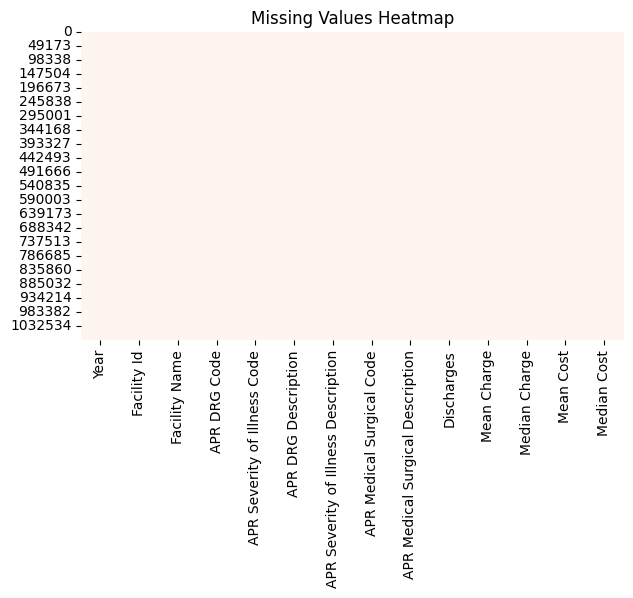

In [37]:
plt.figure(figsize=(7,4))
sns.heatmap(df.isnull(), cbar=False, cmap="Reds")
plt.title("Missing Values Heatmap")
plt.show()


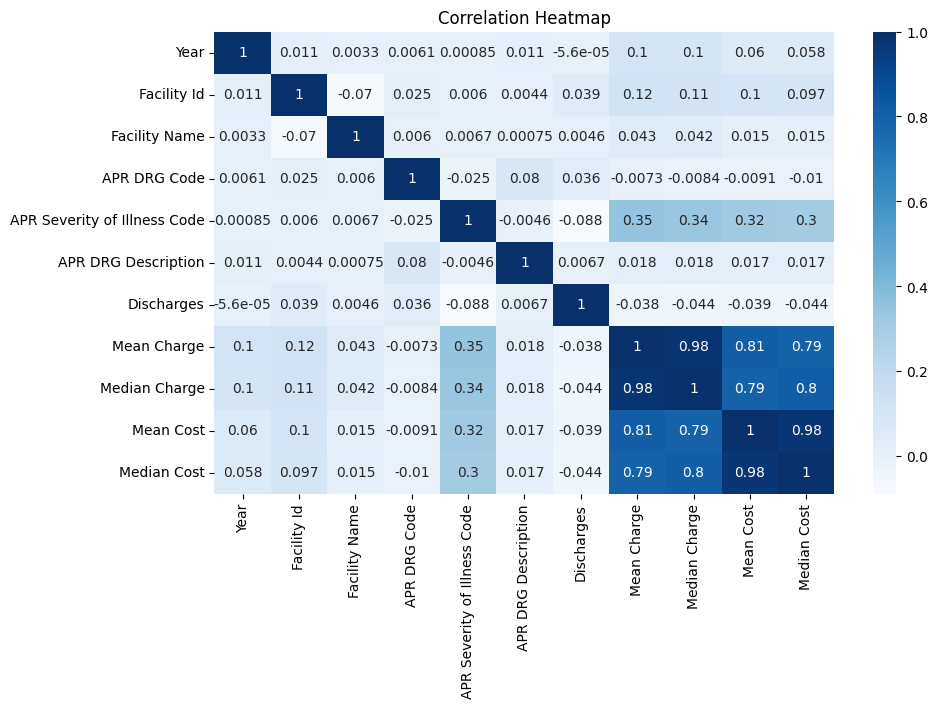

In [38]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()


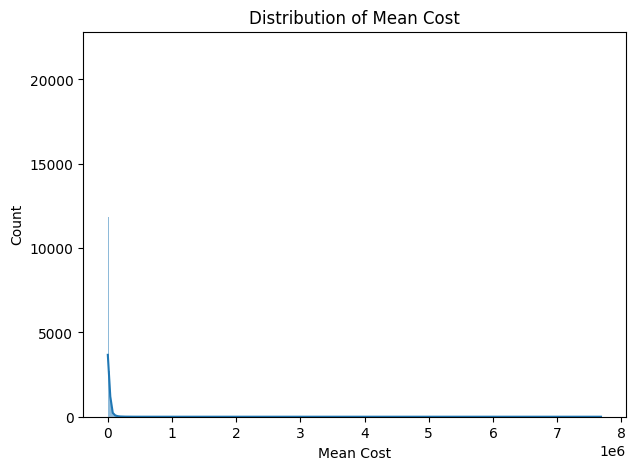

In [39]:
plt.figure(figsize=(7,5))
sns.histplot(df['Mean Cost'], kde=True)
plt.title("Distribution of Mean Cost")
plt.show()


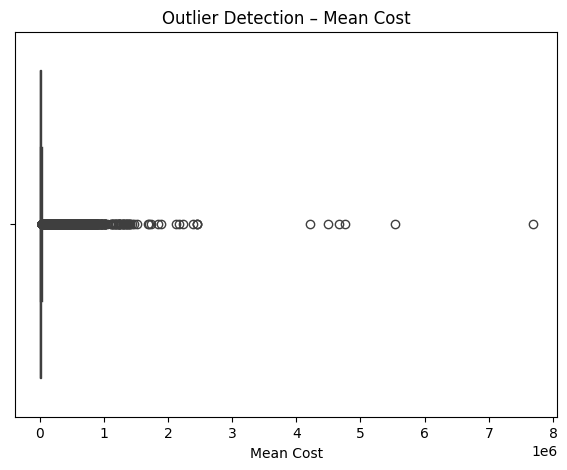

In [40]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df['Mean Cost'])
plt.title("Outlier Detection – Mean Cost")
plt.show()


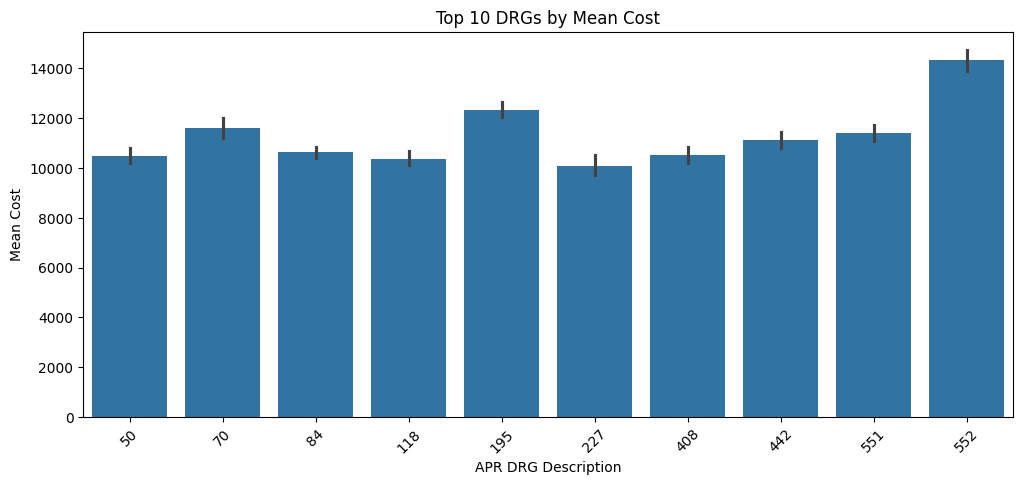

In [41]:
plt.figure(figsize=(12,5))
top_drg = df['APR DRG Description'].value_counts().head(10).index
sns.barplot(data=df[df['APR DRG Description'].isin(top_drg)],
            x='APR DRG Description', y='Mean Cost')
plt.xticks(rotation=45)
plt.title("Top 10 DRGs by Mean Cost")
plt.show()


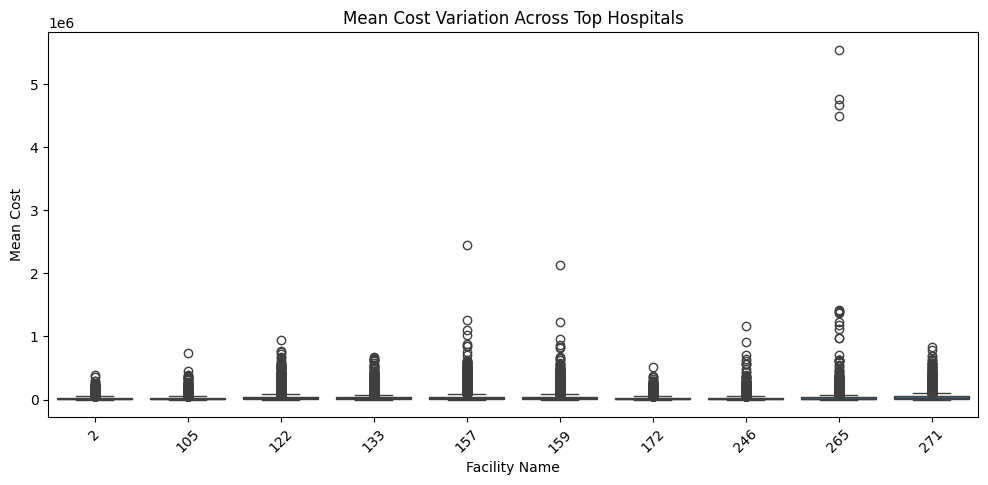

In [42]:
plt.figure(figsize=(12,5))
top_hospitals = df['Facility Name'].value_counts().head(10).index
sns.boxplot(data=df[df['Facility Name'].isin(top_hospitals)],
            x='Facility Name', y='Mean Cost')
plt.xticks(rotation=45)
plt.title("Mean Cost Variation Across Top Hospitals")
plt.show()


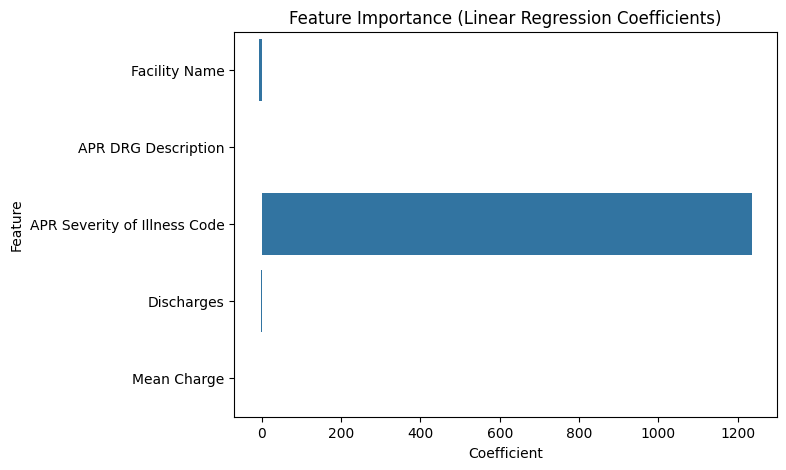

In [43]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

plt.figure(figsize=(7,5))
sns.barplot(data=importance, x='Coefficient', y='Feature')
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()


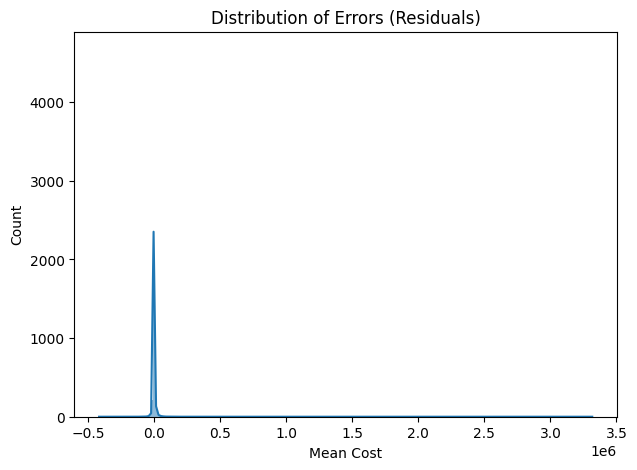

In [44]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Errors (Residuals)")
plt.show()


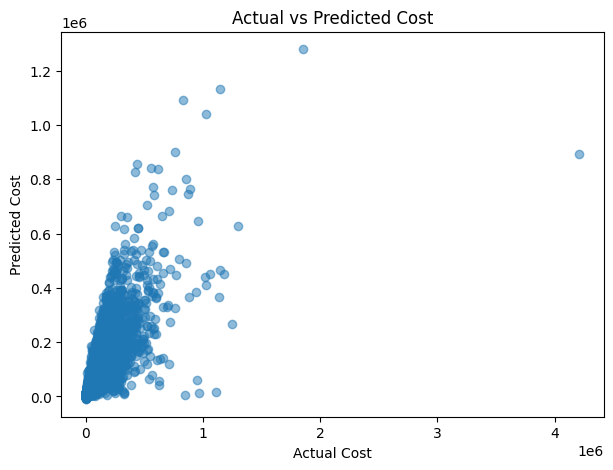

In [45]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Actual vs Predicted Cost")
plt.show()


In [46]:
import pickle
pickle.dump(model, open("medical_cost_model.pkl", "wb"))


In [47]:
import pickle

pickle.dump(le, open("facility_encoder.pkl", "wb"))
pickle.dump(le, open("drg_encoder.pkl", "wb"))


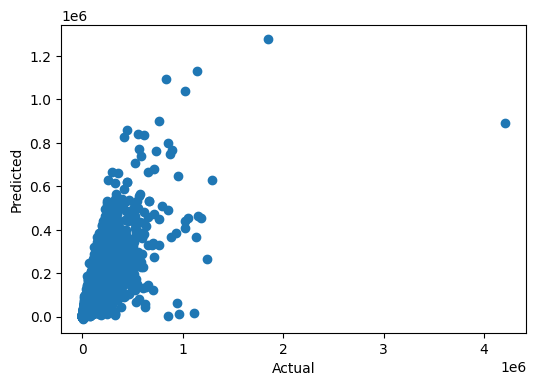

In [48]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.savefig("scatter.png")


In [49]:
import pandas as pd

df = pd.read_csv("Hospital_Inpatient_Cost_Transparency__Beginning.csv")

# Keep only necessary columns
df = df[['Facility Name',
         'APR DRG Description',
         'APR Severity of Illness Code',
         'Discharges',
         'Mean Charge',
         'Mean Cost']]

# Drop rows with missing values
df = df.dropna()

df.head()


,Facility Name,APR DRG Description,APR Severity of Illness Code,Discharges,Mean Charge,Mean Cost
0,Albany Memorial Hospital,Heart Failure,1,2,8375.41,3585.05
1,Albany Memorial Hospital,Heart Failure,2,40,14029.82,6182.67
2,Albany Memorial Hospital,Heart Failure,3,70,23921.77,11149.49
3,Albany Memorial Hospital,Heart Failure,4,12,51260.45,26081.70
4,Albany Memorial Hospital,Cardiac Arrest,4,1,25357.84,7791.75


In [50]:
from sklearn.preprocessing import LabelEncoder

facility_encoder = LabelEncoder()
drg_encoder = LabelEncoder()

df['Facility Enc'] = facility_encoder.fit_transform(df['Facility Name'])
df['DRG Enc'] = drg_encoder.fit_transform(df['APR DRG Description'])


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np

X = df[['Facility Enc', 'DRG Enc', 'APR Severity of Illness Code', 'Discharges', 'Mean Charge']].values
y = df['Mean Cost'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [53]:
import pickle

pickle.dump(model, open("medical_cost_model.pkl", "wb"))
pickle.dump(facility_encoder, open("facility_encoder.pkl", "wb"))
pickle.dump(drg_encoder, open("drg_encoder.pkl", "wb"))
pickle.dump(['Facility Enc','DRG Enc','APR Severity of Illness Code','Discharges','Mean Charge'], open("columns.pkl","wb"))
